In [1]:
# %%
# ==================================
# BLOCK 1 — Imports & Device Setup
# ==================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("GPU Available:", torch.cuda.is_available())

Using device: cuda
GPU Available: True


In [2]:
# %%
# ==================================
# BLOCK 2 — Dataset & Transforms
# ==================================

DATASET_PATH = "Weather-Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2

# EfficientNet normalization (ImageNet standard)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

# Train/Validation split
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoaders (num_workers=0 for Windows stability)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))
print("Training images:", train_size)
print("Validation images:", val_size)

Classes: ['cloudy', 'foggy', 'rainy', 'snowy', 'sunny']
Total images: 18038
Training images: 14431
Validation images: 3607


In [3]:
# %%
# ==================================
# BLOCK 3 — EfficientNetB0 Model
# ==================================

# Load pretrained EfficientNetB0
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Replace classifier layer for 5 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

# Move to GPU
model = model.to(device)

print("EfficientNetB0 loaded successfully.")

EfficientNetB0 loaded successfully.


In [4]:
# %%
# ==================================
# BLOCK 4 — Loss, Optimizer & AMP
# ==================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler()

print("Training components ready.")

Training components ready.


C:\Users\DELL\AppData\Local\Temp\ipykernel_24428\2546856287.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
# %%
# ==================================
# BLOCK 5 — Optimized Training Loop
# ==================================

EPOCHS = 20
best_val_acc = 0

total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")
    
    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # ===== Validation =====
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    
    epoch_time = (time.time() - epoch_start) / 60
    
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Epoch Time: {epoch_time:.2f} minutes")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_weather_model.pth")
        print("Best model saved.")

total_time = (time.time() - total_start) / 60
print(f"\nTraining completed in {total_time:.2f} minutes.")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")


===== Epoch 1/20 =====


Training:   0%|          | 0/451 [00:00<?, ?it/s]C:\Users\DELL\AppData\Local\Temp\ipykernel_24428\1779416021.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Accuracy: 94.77%
Validation Accuracy: 92.04%
Epoch Time: 1.69 minutes
Best model saved.

===== Epoch 2/20 =====


Train Accuracy: 95.79%
Validation Accuracy: 92.10%
Epoch Time: 1.70 minutes
Best model saved.

===== Epoch 3/20 =====


Train Accuracy: 96.71%
Validation Accuracy: 92.18%
Epoch Time: 1.68 minutes
Best model saved.

===== Epoch 4/20 =====


...

Train Accuracy: 98.70%
Validation Accuracy: 92.27%
Epoch Time: 1.69 minutes

===== Epoch 17/20 =====


Train Accuracy: 98.64%
Validation Accuracy: 92.15%
Epoch Time: 1.69 minutes

===== Epoch 18/20 =====


Train Accuracy: 98.78%
Validation Accuracy: 91.99%
Epoch Time: 1.70 minutes

===== Epoch 19/20 =====


Train Accuracy: 98.82%
Validation Accuracy: 91.96%
Epoch Time: 1.69 minutes

===== Epoch 20/20 =====


Train Accuracy: 98.86%
Validation Accuracy: 91.68%
Epoch Time: 1.69 minutes

Training completed in 36.33 minutes.
Best Validation Accuracy: 92.71%


In [10]:
torch.save(model.state_dict(), "last_epoch_model.pth")
print("Final model saved.")

Final model saved.


In [11]:
# %%
# ==================================
# BLOCK 6 — Load Best Saved Model
# ==================================

model.load_state_dict(torch.load("best_weather_model.pth"))
model.eval()

print("Best model loaded for evaluation.")

Best model loaded for evaluation.


C:\Users\DELL\AppData\Local\Temp\ipykernel_24428\3865281602.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_weather_model.pth"))


Classification Report:

              precision    recall  f1-score   support

      cloudy       0.91      0.94      0.92      1326
       foggy       0.93      0.90      0.92       270
       rainy       0.91      0.91      0.91       398
       snowy       0.94      0.92      0.93       363
       sunny       0.95      0.92      0.93      1250

    accuracy                           0.93      3607
   macro avg       0.93      0.92      0.92      3607
weighted avg       0.93      0.93      0.93      3607



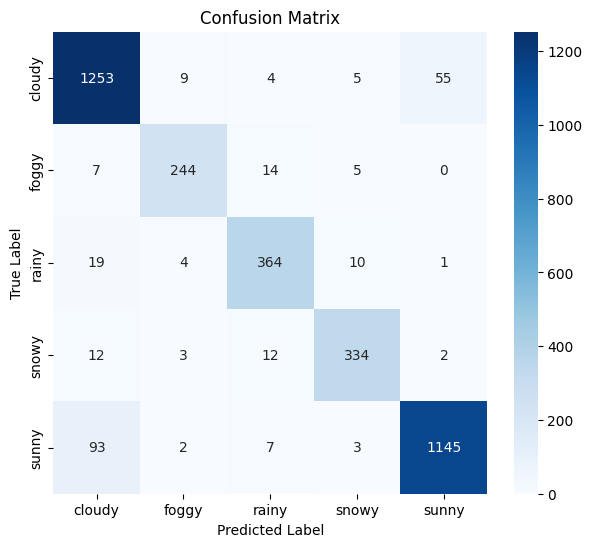

In [12]:
# %%
# ==================================
# BLOCK 7 — Evaluation Metrics
# ==================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get class names
class_names = full_dataset.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()